In [1]:
import pandas as pd

df = pd.read_csv("fuel_prices_history.csv")
df['pull_time'] = pd.to_datetime(df['pull_time'])
df = df.drop_duplicates(subset=['pull_time', 'stationcode', 'fueltype'])
df['day'] = df['pull_time'].dt.date

print("Rows after cleaning:", len(df))
print("Days:", sorted(df['day'].unique()))
df.head()

Rows after cleaning: 328331
Days: [datetime.date(2026, 7, 23), datetime.date(2026, 7, 24), datetime.date(2026, 7, 26), datetime.date(2026, 7, 28), datetime.date(2026, 7, 29), datetime.date(2026, 7, 30), datetime.date(2026, 7, 31), datetime.date(2026, 8, 4), datetime.date(2026, 8, 5), datetime.date(2026, 8, 6), datetime.date(2026, 8, 9), datetime.date(2026, 8, 11)]


,pull_time,stationcode,fueltype,price,lastupdated,day
0,2026-07-23 03:50:53.867731,1,DL,222.9,21/07/2026 20:05:24,2026-07-23
1,2026-07-23 03:50:53.867731,1,E10,185.9,21/07/2026 20:05:24,2026-07-23
2,2026-07-23 03:50:53.867731,1,P95,205.4,21/07/2026 20:05:24,2026-07-23
3,2026-07-23 03:50:53.867731,1,P98,214.9,21/07/2026 20:05:24,2026-07-23
4,2026-07-23 03:50:53.867731,1,U91,187.9,21/07/2026 20:05:24,2026-07-23


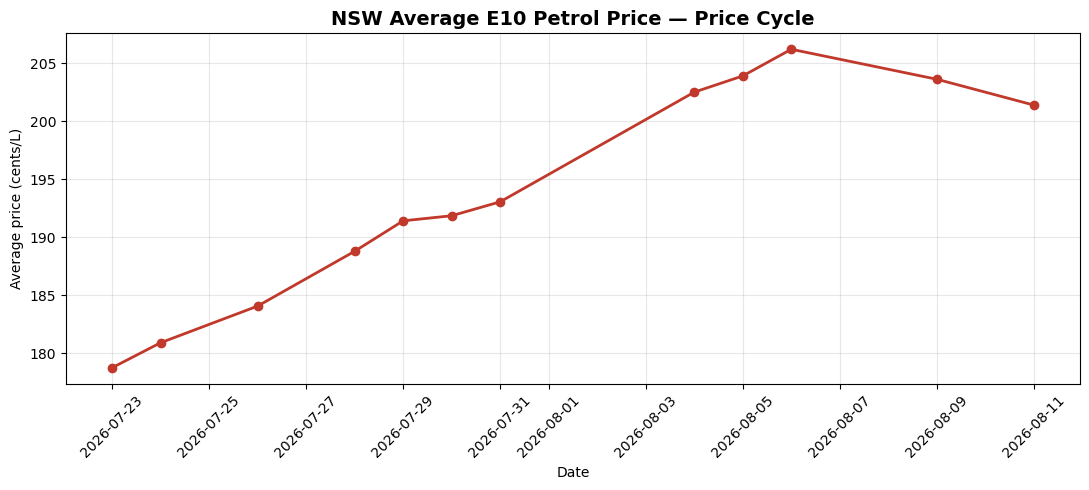

In [2]:
import matplotlib.pyplot as plt

# NSW-wide average E10 price per day
e10 = df[df['fueltype'] == 'E10']
daily_avg = e10.groupby('day')['price'].mean()

plt.figure(figsize=(11, 5))
plt.plot(daily_avg.index, daily_avg.values, marker='o', linewidth=2, color='#c0392b')
plt.title('NSW Average E10 Petrol Price — Price Cycle', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average price (cents/L)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('e10_price_cycle.png', dpi=150)
plt.show()

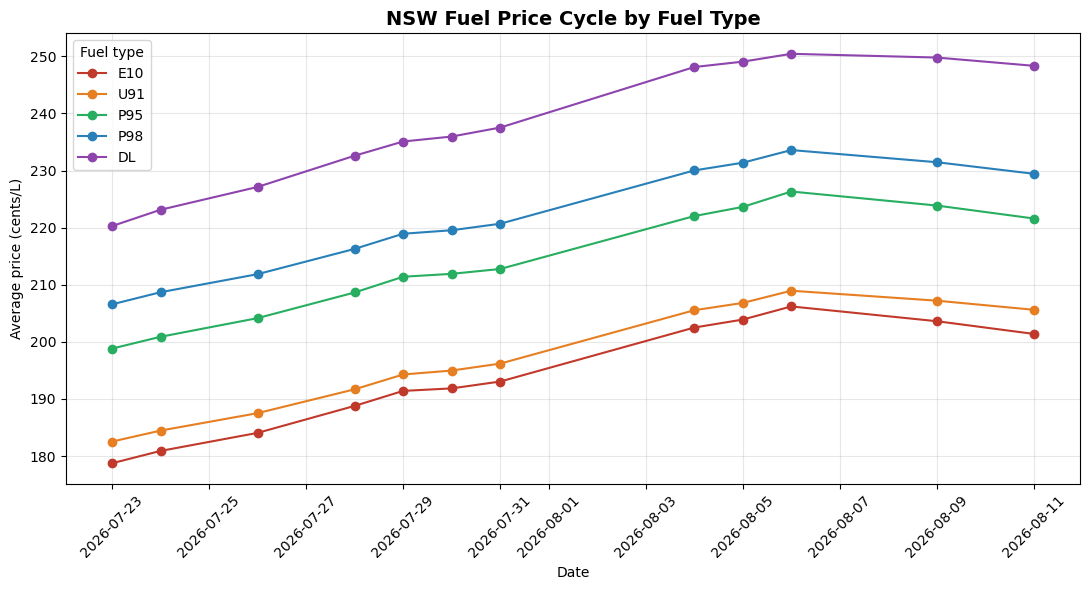

In [3]:
fuel_types = ['E10', 'U91', 'P95', 'P98', 'DL']
colors = ['#c0392b', '#e67e22', '#27ae60', '#2980b9', '#8e44ad']

plt.figure(figsize=(11, 6))

for fuel, color in zip(fuel_types, colors):
    subset = df[df['fueltype'] == fuel]
    daily = subset.groupby('day')['price'].mean()
    plt.plot(daily.index, daily.values, marker='o', label=fuel, color=color)

plt.title('NSW Fuel Price Cycle by Fuel Type', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average price (cents/L)')
plt.legend(title='Fuel type')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('price_by_fueltype.png', dpi=150)
plt.show()

In [4]:
# Find the average price on the first day vs the peak day for each fuel type
summary = df.groupby(['fueltype', 'day'])['price'].mean().reset_index()

# Pivot so each fuel type is a row, each day a column
pivot = summary.pivot(index='fueltype', columns='day', values='price')

# Calculate the total climb from start to peak for the main fuels
main_fuels = ['E10', 'U91', 'P95', 'P98', 'DL']
print("Price movement over the cycle (cents/L):\n")
for fuel in main_fuels:
    row = pivot.loc[fuel].dropna()
    start = row.iloc[0]
    peak = row.max()
    end = row.iloc[-1]
    print(f"{fuel:4} | start: {start:.1f} | peak: {peak:.1f} | now: {end:.1f} | total climb: +{peak-start:.1f}")

Price movement over the cycle (cents/L):

E10  | start: 178.7 | peak: 206.2 | now: 201.4 | total climb: +27.5
U91  | start: 182.5 | peak: 209.0 | now: 205.6 | total climb: +26.4
P95  | start: 198.8 | peak: 226.3 | now: 221.6 | total climb: +27.5
P98  | start: 206.6 | peak: 233.6 | now: 229.4 | total climb: +27.0
DL   | start: 220.3 | peak: 250.5 | now: 248.3 | total climb: +30.2


In [5]:
# Build a clean daily time series: average E10 price per day
e10 = df[df['fueltype'] == 'E10'].copy()
daily = e10.groupby('day')['price'].mean().reset_index()
daily.columns = ['date', 'avg_price']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date').reset_index(drop=True)

print(daily)

         date   avg_price
0  2026-07-23  178.734812
1  2026-07-24  180.892693
2  2026-07-26  184.054002
3  2026-07-28  188.778967
4  2026-07-29  191.407229
5  2026-07-30  191.846113
6  2026-07-31  193.047890
7  2026-08-04  202.503217
8  2026-08-05  203.901991
9  2026-08-06  206.201273
10 2026-08-09  203.614544
11 2026-08-11  201.386586


In [6]:
# Naive baseline: predict tomorrow's price = today's price
daily['naive_forecast'] = daily['avg_price'].shift(1)

# Error = how far off the naive guess was, each day
daily['naive_error'] = daily['avg_price'] - daily['naive_forecast']

# Drop the first row (no previous day to predict from)
baseline = daily.dropna(subset=['naive_forecast'])

mae = baseline['naive_error'].abs().mean()
rmse = (baseline['naive_error'] ** 2).mean() ** 0.5

print("Naive baseline (tomorrow = today):")
print(f"MAE:  {mae:.2f} cents/L")
print(f"RMSE: {rmse:.2f} cents/L")
print("\nThis is the bar any real model has to beat.")

Naive baseline (tomorrow = today):
MAE:  2.93 cents/L
RMSE: 3.74 cents/L

This is the bar any real model has to beat.


In [7]:
import numpy as np

# Turn dates into simple numbers (day 0, 1, 2, ...) so we can fit a line
daily['day_num'] = range(len(daily))

# Fit a straight line (linear trend) through the prices
coeffs = np.polyfit(daily['day_num'], daily['avg_price'], deg=1)
trend = np.poly1d(coeffs)

# Predict each day using the trend line
daily['trend_forecast'] = trend(daily['day_num'])
daily['trend_error'] = daily['avg_price'] - daily['trend_forecast']

trend_mae = daily['trend_error'].abs().mean()
trend_rmse = (daily['trend_error'] ** 2).mean() ** 0.5

print("Linear trend model:")
print(f"MAE:  {trend_mae:.2f} cents/L")
print(f"RMSE: {trend_rmse:.2f} cents/L")
print(f"\nBaseline was MAE 2.93 — did we beat it? {'YES' if trend_mae < 2.93 else 'NO'}")

Linear trend model:
MAE:  2.45 cents/L
RMSE: 2.97 cents/L

Baseline was MAE 2.93 — did we beat it? YES


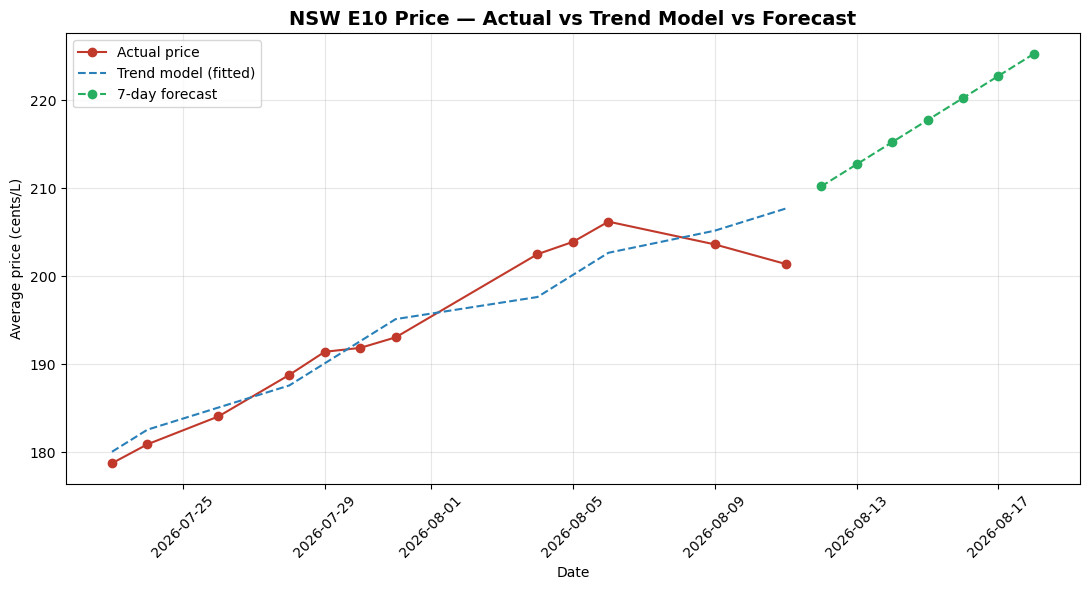

In [8]:
import matplotlib.pyplot as plt

# Project the trend forward 7 days
future_days = range(len(daily), len(daily) + 7)
future_dates = pd.date_range(daily['date'].iloc[-1], periods=8, freq='D')[1:]
future_prices = trend(list(future_days))

plt.figure(figsize=(11, 6))
plt.plot(daily['date'], daily['avg_price'], marker='o', label='Actual price', color='#c0392b')
plt.plot(daily['date'], daily['trend_forecast'], '--', label='Trend model (fitted)', color='#2980b9')
plt.plot(future_dates, future_prices, 'o--', label='7-day forecast', color='#27ae60')

plt.title('NSW E10 Price — Actual vs Trend Model vs Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average price (cents/L)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('forecast.png', dpi=150)
plt.show()